In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("PD_customer_data.csv")
df["order_date"] = pd.to_datetime(df["order_date"])
df["delivery_date"] = pd.to_datetime(df["delivery_date"])
df["order_value"] = df["quantity"] * df["price"]
df_revenue = df[df["order_status"] == "Delivered"]
df

,order_id,customer_id,customer_city,customer_segment,order_date,delivery_date,product_category,product_name,quantity,price,payment_method,order_status,order_value
0,200000,C03407,Pune,Corporate,2023-08-31,2023-09-05,Electronics,Wireless Mouse,3,2132,Debit Card,Delivered,6396
1,200001,C00758,Delhi,Small Business,2023-08-05,2023-08-10,Electronics,Smart Watch,2,7709,Cash on Delivery,Delivered,15418
2,200002,C03625,Bangalore,Consumer,2023-02-05,NaT,Electronics,Power Bank,2,4942,UPI,Cancelled,9884
3,200003,R00170,Hyderabad,Corporate,2023-07-13,2023-07-20,Fashion,Shoes,4,3928,Cash on Delivery,Delivered,15712
4,200004,C03236,Chennai,Corporate,2023-09-29,2023-10-05,Home,Electric Kettle,1,4841,Debit Card,Delivered,4841
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,204995,R00558,Delhi,Small Business,2023-10-11,NaT,Electronics,Wireless Mouse,2,4209,UPI,Returned,8418
4996,204996,C02551,Mumbai,Corporate,2023-09-16,NaT,Fashion,Shoes,3,2639,Cash on Delivery,Returned,7917
4997,204997,C00538,Hyderabad,Corporate,2023-07-13,2023-07-16,Fashion,Shoes,5,6794,UPI,Delivered,33970
4998,204998,C01221,Mumbai,Corporate,2023-03-26,2023-03-31,Home,Electric Kettle,5,1133,Cash on Delivery,Delivered,5665


In [11]:
#Revenue analysis
#What is the total revenue and total delivered revenue?
total_revenue = df["order_value"].sum() #63801119
total_delivered_revenue = df_revenue["order_value"].sum() #45711608
#What is the average order value (AOV) overall and by month?
AOV = df_revenue["order_value"].mean() #12851
AOV_by_month = df.groupby(df_revenue["order_date"].dt.to_period("M"))["order_value"].mean()
#Which month shows the highest and lowest revenue?
df.groupby(df_revenue["order_date"].dt.to_period("M"))["order_value"].sum().idxmax() #January 2023
df.groupby(df_revenue["order_date"].dt.to_period("M"))["order_value"].sum().idxmin() #February 2023
#How much revenue is lost due to Cancelled + Returned orders?
lost_revenue_df = df[df["order_status"].isin(["Cancelled", "Returned"])]
lost_revenue = lost_revenue_df["order_value"].sum()
(lost_revenue)/(total_revenue) * 100  #28.35%

# revenue contribution by product category - 
category_sum = df.groupby("product_category")["order_value"].sum()
category_sum.sort_values(ascending = False)
#Fashion        21504059
#Home           21281071
#Electronics    21015989
#AOV by product category
AOV_by_product_category = df.groupby("product_category")["order_value"].mean()
#Calculate monthly revenue trend
monthly_revenue = (
    df_revenue
        .groupby(df_revenue["order_date"].dt.to_period("M"))["order_value"]
        .sum()
        .reset_index()
)
monthly_revenue
#What is the month-over-month (MoM) growth rate?
monthly_revenue["mom_growth"] = monthly_revenue["order_value"].pct_change()*100 
monthly_revenue
#PERCENTAGE OF REVENUE FROM ELECTRONICS
electronics_revenue = df[df["product_category"] == "Electronics"]["order_value"].sum()
total_revenue = df["order_value"].sum()
(electronics_revenue / total_revenue) * 100  #32.93%
#AVG DELIVERY TIME
df["delivery_time"] = (df["delivery_date"] - df["order_date"]).dt.days
df["delivery_time"].mean() #5.07 Days

np.float64(5.0787180208040485)

In [12]:
#SEGMENT ANALYSIS
#total revenue per segment
total_revenue_per_segment = df.groupby("customer_segment")["order_value"].sum()
segment_percentage = (total_revenue_per_segment/ total_revenue_per_segment.sum()) * 100
#Find average revenue per customer segment
avg_revenue_per_segment = df_revenue.groupby("customer_segment")["order_value"].mean()
avg_revenue_per_segment.sort_values(ascending = False)
#Consumer          13043.521002
#Corporate         12775.512090
#Small Business    12721.521102
#Which segment places higher-value orders on average? AOV
df_revenue.groupby("customer_segment")["order_value"].mean().sort_values(ascending=False) #Consumer-13043
#What is the average CLV by customer segment?
df_revenue["clv"] = (
    df_revenue
    .groupby("customer_id")["order_value"]
    .transform("sum")
)
avg_clv_by_segment = (
    df_revenue
    .groupby("customer_segment")["clv"]
    .mean()
)

avg_clv_by_segment
#Consumer          15452.173667
#Corporate         14964.217617
#Small Business    15279.336779
#Which customer segment contributes the most revenue? #Consumer    16147879
df_revenue.groupby("customer_segment")["order_value"].sum().head(1)
#RETURN RATE PER SEGMENT
return_rate = ( df[df["order_status"] == "Returned"] .groupby("customer_segment") .size() ) #count the number of orders returned per segment
total_orders_segment = df.groupby("customer_segment").size() #count total number of orders per segment
(return_rate / total_orders_segment) * 100
#Consumer           9.808474
#Corporate          9.561510
#Small Business    10.642202
#Which customer segment returns the most orders?
returned_orders = (
    df[df["order_status"] == "Returned"]
      .groupby("customer_segment")
      .size()
)

returned_orders
#Consumer          169
#Corporate         157
#Small Business    174

C:\Users\asdminn\AppData\Local\Temp\ipykernel_7628\1835427077.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_revenue["clv"] = (


customer_segment
Consumer          169
Corporate         157
Small Business    174
dtype: int64

In [13]:
#CITY BASED ANALYSIS
#Which cities have the highest avg CLV ? avg clv by city
df_revenue.groupby("customer_city")["clv"].mean().sort_values(ascending = False) 
#Chennai      15686.120339
#Bangalore    15466.978078
#Mumbai       15351.513912
#CITY WITH THE HIGHEST AOV
highest_AOV_city = df.groupby("customer_city")["order_value"].mean().head(1) #Bangalore    12925
#Find top 3 cities by revenue.
highest_revenue_cities = df.groupby("customer_city")["order_value"].sum().sort_values(ascending = False).head(3)
highest_revenue_cities
#Delhi        10844458
#Hyderabad    10713478
#Mumbai       10706092
#Which cities have the highest number of customers?
df.groupby("customer_city")["customer_id"].nunique().sort_values(ascending = False)

customer_city
Delhi        835
Mumbai       828
Chennai      827
Hyderabad    811
Pune         793
Bangalore    785
Name: customer_id, dtype: int64

In [14]:
#CUSTOMER ANALYSIS
#customer lifetime value
clv = (
    df_revenue.groupby("customer_id")["order_value"]
    .sum()
)
clv = clv.sort_values(ascending = False)
#Who are the top 10 customers by lifetime value (CLV)?
clv.head(10)
#What percentage of customers are repeat buyers? RETENTION RATE
orders_per_customer = df.groupby("customer_id").size()
orders_per_customer
repeat_customers = orders_per_customer[orders_per_customer > 1]

repeat_buyer_percentage = (
    len(repeat_customers) / orders_per_customer.count()
) * 100

repeat_buyer_percentage #14.28%
#churn rate - customers that dont return
one_time_customers = orders_per_customer[orders_per_customer == 1]
churn_rate = (
    len(one_time_customers) / orders_per_customer.count()
) * 100
churn_rate #85.71%
#how many unique customers are there?
unique_customers = df["customer_id"].nunique()
unique_customers #4375

4375

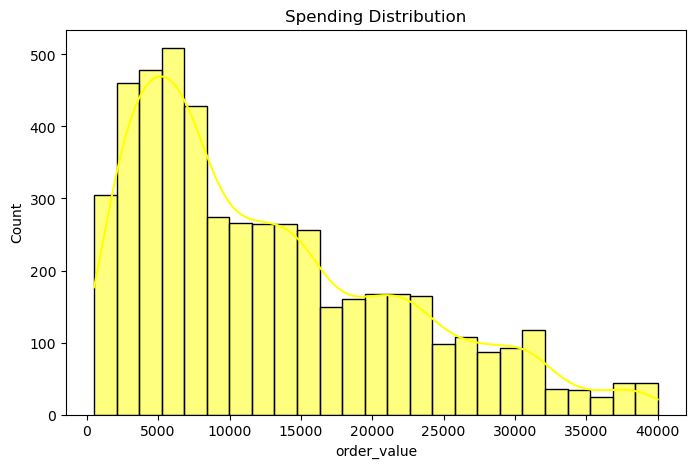

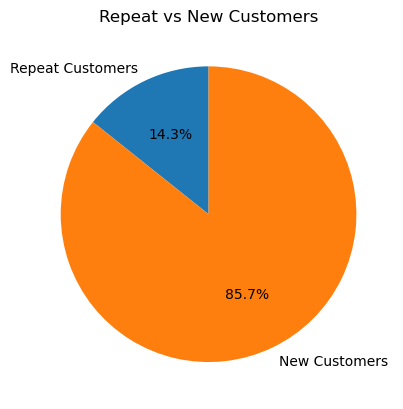

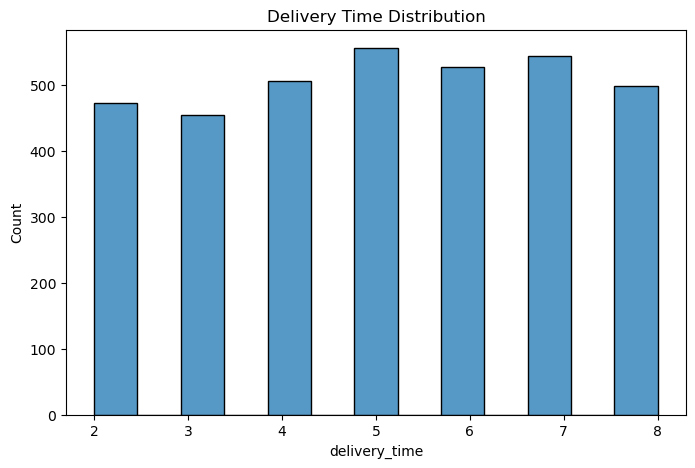

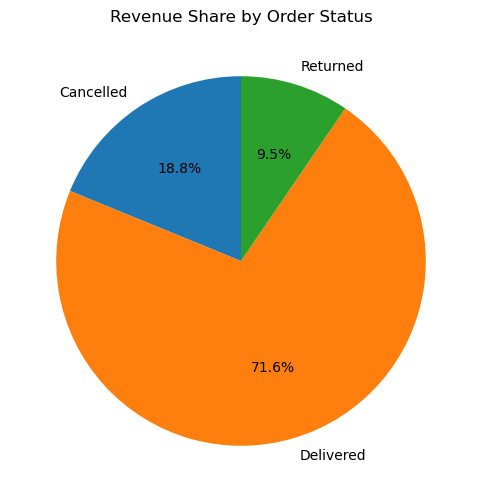

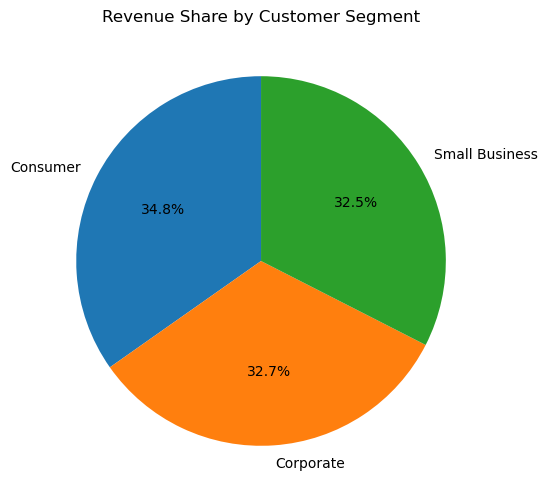

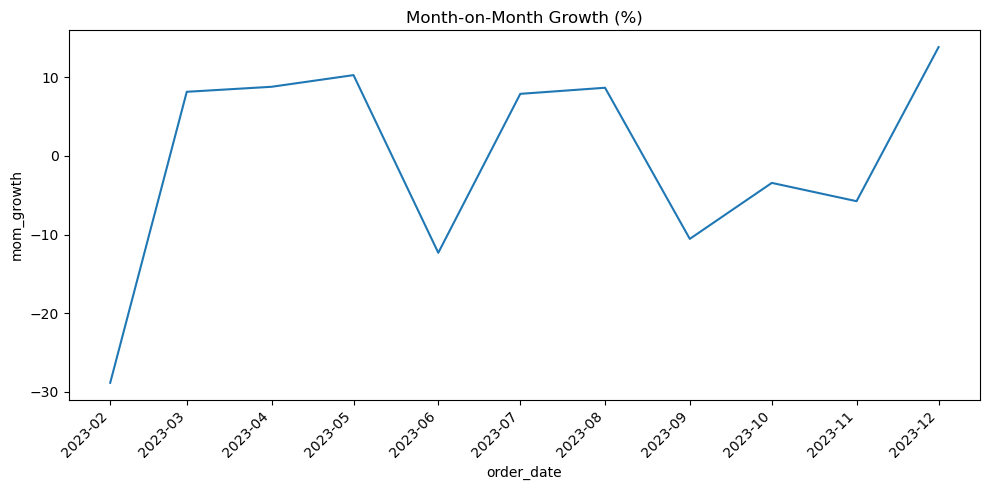

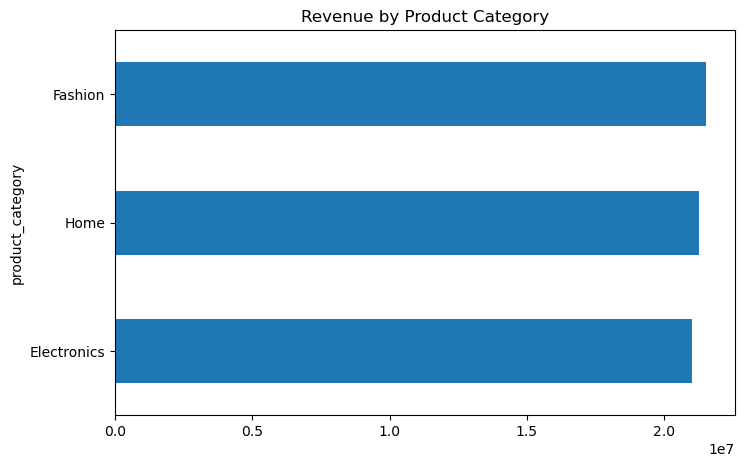

In [22]:
#DATA VISUALIZATION
plt.figure(figsize=(8,5))
sns.histplot(df["order_value"], kde=True,color = "yellow")
plt.title("Spending Distribution")
plt.show()

customer_orders = df["customer_id"].value_counts()
repeat_customers = (customer_orders > 1).sum()
new_customers = (customer_orders == 1).sum()
plt.pie([repeat_customers, new_customers],
        labels=["Repeat Customers", "New Customers"],
        autopct="%1.1f%%",
        startangle=90)
plt.title("Repeat vs New Customers")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["delivery_time"])
plt.title("Delivery Time Distribution")
plt.show()

status_revenue = df.groupby("order_status")["order_value"].sum()

plt.figure(figsize=(6,6))
plt.pie(status_revenue,
        labels=status_revenue.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Revenue Share by Order Status")
plt.show()

segment_revenue = df.groupby("customer_segment")["order_value"].sum()
plt.figure(figsize=(6,6))
plt.pie(segment_revenue,
        labels=segment_revenue.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Revenue Share by Customer Segment")
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x="order_date", y="mom_growth")
plt.xticks(rotation=45, ha="right")
plt.title("Month-on-Month Growth (%)")
plt.tight_layout()
plt.show()

